In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.special import ellipj

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

torch.manual_seed(123)
torch.set_default_dtype(torch.float32)

def exact_solution(t):
    t_cpu = t.detach().cpu().numpy()
    cn = ellipj(2.0 * t_cpu, 0.25)[1]
    return torch.tensor(cn, dtype=t.dtype, device=t.device)

# Neural Network
class FCN(nn.Module):
    def __init__(self, hidden=64, layers=4):
        super().__init__()
        act = nn.Tanh
        modules = [nn.Linear(1, hidden), act()]
        for _ in range(layers - 1):
            modules += [nn.Linear(hidden, hidden), act()]
        modules += [nn.Linear(hidden, 2)]
        self.net = nn.Sequential(*modules)

    def forward(self, t):
        return self.net(t)

Using device: mps


Step      0 | Loss = 1.051e+00 | MSE = 4.778e-01


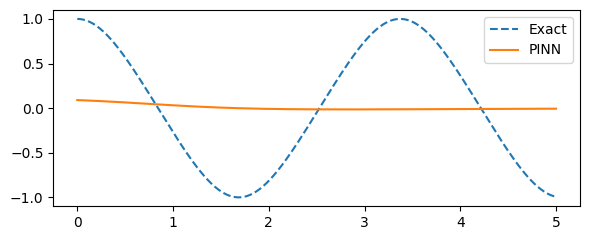

Step  10000 | Loss = 4.931e-05 | MSE = 9.476e-01


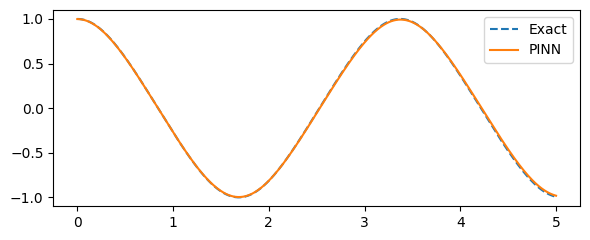

Step  20000 | Loss = 5.203e-05 | MSE = 9.517e-01


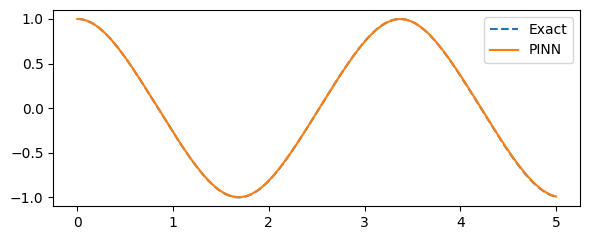

Step  30000 | Loss = 6.176e-06 | MSE = 9.509e-01


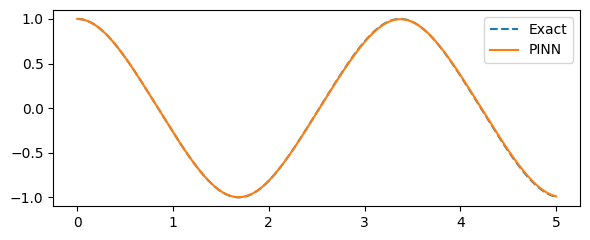

Step  40000 | Loss = 1.256e-05 | MSE = 9.530e-01


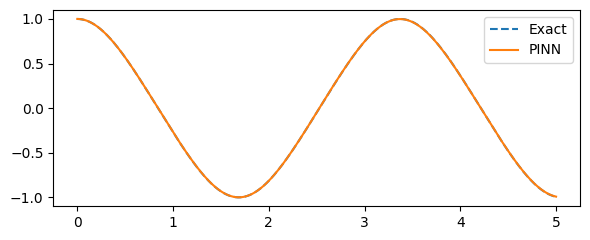

KeyboardInterrupt: 

In [3]:
# Model
model = FCN(hidden=64, layers=4).to(device)

# Time grids
t0 = torch.tensor([[0.0]], device=device, requires_grad=True)

t_phys = torch.linspace(0.0, 5.0, 400, device=device).view(-1, 1)
t_phys.requires_grad_(True)

t_test = torch.linspace(0.0, 5.0, 600, device=device).view(-1, 1)
x_exact = exact_solution(t_test)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Loss function 
def pinn_loss():
    # Initial condition
    uv0 = model(t0)
    x0, v0 = uv0[:, 0:1], uv0[:, 1:2]
    loss_ic = (x0 - 1.0)**2 + v0**2

    # Physics
    uv = model(t_phys)
    x, v = uv[:, 0:1], uv[:, 1:2]

    dxdt = torch.autograd.grad(
        x, t_phys, torch.ones_like(x), create_graph=True
    )[0]

    dvdt = torch.autograd.grad(
        v, t_phys, torch.ones_like(v), create_graph=True
    )[0]

    res_x = dxdt - v
    res_v = dvdt + 2.0*x + 2.0*x**3
    loss_phys = torch.mean(res_x**2 + res_v**2)

    # Energy conservation
    H = 0.5*v**2 + x**2 + 0.5*x**4
    H0 = (0.5*v0**2 + x0**2 + 0.5*x0**4).detach()
    loss_energy = torch.mean((H - H0)**2)

    return loss_ic + loss_phys #+ loss_energy


# Training
for i in range(60001):
    optimizer.zero_grad()
    loss = pinn_loss()
    loss.backward()
    optimizer.step()

    if i % 10000 == 0:
        with torch.no_grad():
            x_pred = model(t_test)[:, 0]
            mse = torch.mean((x_pred - x_exact)**2).item()

        print(f"Step {i:6d} | Loss = {loss.item():.3e} | MSE = {mse:.3e}")

        plt.figure(figsize=(6, 2.5))
        plt.plot(t_test.cpu()[:,0], x_exact.cpu(), "--", label="Exact")
        plt.plot(t_test.cpu()[:,0], x_pred.cpu(), label="PINN")
        plt.legend()
        plt.tight_layout()
        plt.show()